# Multi‑Objective Optimisation with Genetic Algorithms (NSGA‑II)

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates the application of genetic algorithms to multi‑objective optimisation problems. Multi‑objective optimisation involves optimising two or more conflicting objectives simultaneously. The solutions form a **Pareto front**, where no single solution is better in all objectives.

We cover two case studies:

1. **The Dent Problem** – a bi‑objective test function with a non‑smooth Pareto front.
2. **Portfolio Optimisation** – maximising expected return while minimising risk.

**Key Concepts Covered:**

- **Multi‑objective Optimisation** – conflicting objectives and Pareto dominance.
- **NSGA‑II** – Non‑dominated Sorting Genetic Algorithm II (fast non‑dominated sorting, crowding distance, elitism).
- **Pareto Front** – visualisation of trade‑off solutions.
- **Constraint Handling** – via custom operators and normalisation.

**Key Techniques & Libraries:**
- `deap` – framework for evolutionary algorithms.
- `numpy`, `matplotlib` – numerical operations and visualisation.
- `random`, `math` – random operations and mathematical functions.

**Objective:**
To understand the principles of multi‑objective optimisation and to implement NSGA‑II using the DEAP library, applied to both synthetic and real‑world problems.

In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

print("All imports successful.")

All imports successful.


## Multi‑Objective Optimisation Overview

In multi‑objective optimisation, we have multiple objective functions $f_1, f_2, ..., f_m$ that we wish to optimise simultaneously. These objectives are often in conflict.

A solution $\mathbf{x}$ is said to **dominate** another solution $\mathbf{y}$ if:
- $\mathbf{x}$ is no worse than $\mathbf{y}$ in all objectives.
- $\mathbf{x}$ is strictly better than $\mathbf{y}$ in at least one objective.

The set of non‑dominated solutions is called the **Pareto front**. The goal is to find a diverse set of solutions approximating the true Pareto front.

We use the **NSGA‑II** algorithm, which is a popular evolutionary algorithm for multi‑objective optimisation. It features:
- Fast non‑dominated sorting.
- Crowding distance for diversity preservation.
- Elitism via an elite preservation strategy.

## Case Study 1: The Dent Problem

The Dent problem is a bi‑objective test function defined over two variables $x_1, x_2 \in [-1.5, 1.5]$. The objectives are:

$$
f_1(x_1, x_2) = 0.5\left( \sqrt{1 + (x_1+x_2)^2} + \sqrt{1 + (x_1-x_2)^2} + x_1 - x_2 \right) + d
$$

$$
f_2(x_1, x_2) = 0.5\left( \sqrt{1 + (x_1+x_2)^2} + \sqrt{1 + (x_1-x_2)^2} - x_1 + x_2 \right) + d
$$

where $d = \lambda \cdot \exp(-(x_1 - x_2)^2)$ and $\lambda$ is a parameter (default 0.85).

The Pareto front of this problem has a "dent" or non‑smooth shape, making it a good test for multi‑objective optimisers.

In [2]:
def dent(individual, lbda=0.85):
    """
    Dent function: two objectives, two variables.
    Variables in [-1.5, 1.5].
    """
    x1, x2 = individual
    d = lbda * math.exp(-(x1 - x2) ** 2)
    term = 0.5 * (math.sqrt(1 + (x1 + x2) ** 2) + math.sqrt(1 + (x1 - x2) ** 2))
    f1 = term + 0.5 * (x1 - x2) + d
    f2 = term + 0.5 * (-x1 + x2) + d
    return f1, f2

# DEAP setup for Dent
toolbox_dent = base.Toolbox()

creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))  # both objectives minimised
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox_dent.register("attr_float", random.uniform, -1.5, 1.5)
toolbox_dent.register("individual", tools.initRepeat, creator.Individual, toolbox_dent.attr_float, n=2)
toolbox_dent.register("population", tools.initRepeat, list, toolbox_dent.individual)
toolbox_dent.register("mate", tools.cxBlend, alpha=0.5)
toolbox_dent.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.1, indpb=0.2)
toolbox_dent.register("evaluate", dent)
toolbox_dent.register("select", tools.selNSGA2)

### Running NSGA‑II on the Dent Problem

We run NSGA‑II with a population size of 50 for 10 generations. The algorithm finds the Pareto front, which we visualise together with a sample of feasible solutions.

In [3]:
# Parameters
POP_SIZE = 50
MAX_GEN = 10
MUT_PROB = 0.2

def run_nsga2(toolbox, pop_size, max_gen, mut_prob, stats=None, verbose=False):
    pop = toolbox.population(n=pop_size)
    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])
    # Use eaMuPlusLambda with selection=selNSGA2 already registered
    pop, logbook = algorithms.eaMuPlusLambda(
        pop, toolbox, mu=pop_size, lambda_=pop_size,
        cxpb=1.0 - mut_prob, mutpb=mut_prob,
        stats=stats, ngen=max_gen, verbose=verbose
    )
    # Extract Pareto front
    pareto_front = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    return pop, logbook, pareto_front

# Statistics
stats_dent = tools.Statistics(key=lambda ind: ind.fitness.values)
stats_dent.register("avg", np.mean, axis=0)
stats_dent.register("std", np.std, axis=0)
stats_dent.register("min", np.min, axis=0)
stats_dent.register("max", np.max, axis=0)

# Run
pop_dent, log_dent, front_dent = run_nsga2(toolbox_dent, POP_SIZE, MAX_GEN, MUT_PROB, stats=stats_dent, verbose=True)

gen	nevals	avg                    	std                    	min                    	max                    
0  	50    	[2.11067842 1.85159779]	[0.59986495 0.63130632]	[0.66605543 0.60286207]	[3.08219496 2.86183604]
1  	50    	[1.80633667 1.76409642]	[0.82839699 0.83767117]	[0.64004809 0.60286207]	[4.47842344 3.85795503]
2  	50    	[1.65632879 1.69867149]	[0.73144284 0.75966861]	[0.59673341 0.60286207]	[3.08219496 3.85795503]
3  	50    	[1.69169834 1.68027815]	[0.80138289 0.73983291]	[0.59673341 0.57742368]	[4.41898144 3.85795503]
4  	50    	[1.72953031 1.67050781]	[0.83779159 0.79746247]	[0.58910096 0.57742368]	[4.41898144 3.85795503]
5  	50    	[1.80182018 1.61534491]	[0.88582617 0.88731105]	[0.5694355  0.57742368]	[4.41898144 5.09704789]
6  	50    	[1.72917371 1.65923751]	[0.92279793 0.91292291]	[0.5694355  0.57742368]	[4.41898144 5.09704789]
7  	50    	[1.81848107 1.63123338]	[1.01489697 0.9477956 ]	[0.5694355  0.57638366]	[4.89797919 5.09704789]
8  	50    	[1.79651495 1.67335115]	[1

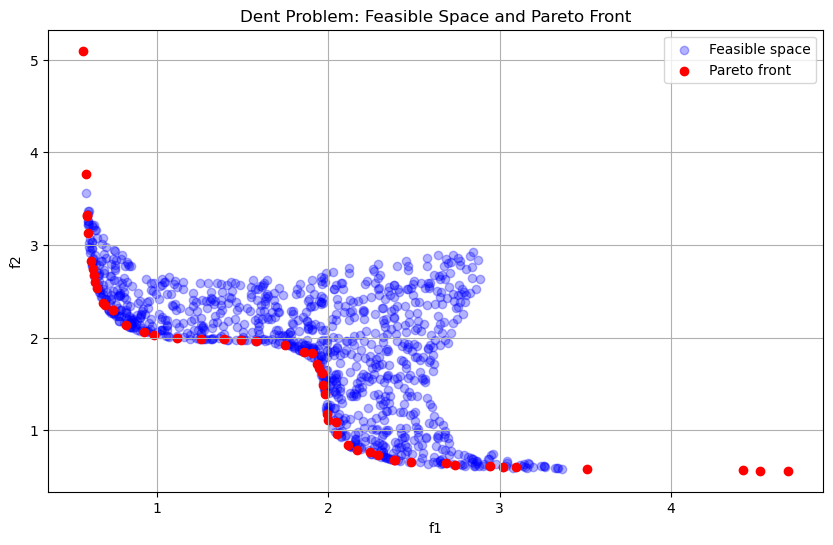

In [4]:
# Generate random feasible solutions for visualisation
n_samples = 1000
samples = [creator.Individual([random.uniform(-1.5, 1.5) for _ in range(2)]) for _ in range(n_samples)]
evaluated_samples = np.array([dent(ind) for ind in samples])

# Pareto front points
pareto_points = np.array([ind.fitness.values for ind in front_dent])

plt.figure(figsize=(10, 6))
plt.scatter(evaluated_samples[:, 0], evaluated_samples[:, 1], c='blue', alpha=0.3, label='Feasible space')
plt.scatter(pareto_points[:, 0], pareto_points[:, 1], c='red', label='Pareto front')
plt.xlabel('f1')
plt.ylabel('f2')
plt.title('Dent Problem: Feasible Space and Pareto Front')
plt.legend()
plt.grid(True)
plt.show()

## Case Study 2: Multi‑Objective Portfolio Optimisation

We now apply NSGA‑II to a financial portfolio optimisation problem. We have 5 assets with expected returns and a covariance matrix. The objectives are:

1. Maximise expected return: $f_1 = \sum_{i} x_i \cdot r_i$
2. Minimise risk (variance): $f_2 = \mathbf{x}^T \Sigma \mathbf{x}$

Constraints:
- $\sum_i x_i = 1$ (fully invested)
- $x_i \ge 0$ (no short selling)

We use a custom normalisation to ensure the sum equals 1, and we apply polynomial mutation and simulated binary crossover with bounds to maintain feasibility.

In [5]:
# Asset data
returns = np.array([0.05, 0.18, 0.15, 0.10, 0.08])
cov_matrix = np.array([
    [0.10, 0.01, 0.02, 0.03, 0.04],
    [0.01, 0.07, 0.05, 0.06, 0.07],
    [0.02, 0.05, 0.05, 0.08, 0.05],
    [0.03, 0.06, 0.08, 0.07, 0.03],
    [0.04, 0.07, 0.05, 0.03, 0.08]
])
n_assets = len(returns)

def normalize(individual):
    """Normalise weights to sum to 1."""
    total = sum(individual)
    if total == 0:
        return [1.0 / len(individual)] * len(individual)
    return [x / total for x in individual]

def evaluate_portfolio(individual):
    """Return (return, risk) for a portfolio."""
    w = normalize(individual)
    ret = np.dot(w, returns)
    risk = np.dot(w, np.dot(cov_matrix, w))
    return ret, risk

# Custom crossover and mutation to maintain sum=1 and bounds [0,1]
def custom_mutate(individual, low, up, eta, indpb):
    mutated = tools.mutPolynomialBounded(individual, low=low, up=up, eta=eta, indpb=indpb)[0]
    # Normalise to sum to 1
    norm = normalize(mutated)
    return (creator.Individual(norm),)

def custom_cx(ind1, ind2, low, up, eta):
    c1, c2 = tools.cxSimulatedBinaryBounded(ind1, ind2, eta, low, up)
    c1 = creator.Individual(normalize(c1))
    c2 = creator.Individual(normalize(c2))
    return c1, c2

In [6]:
# Create new types for portfolio (maximise return, minimise risk)
creator.create("FitnessPortfolio", base.Fitness, weights=(1.0, -1.0))  # return max, risk min
creator.create("IndividualPortfolio", list, fitness=creator.FitnessPortfolio)

toolbox_portfolio = base.Toolbox()
toolbox_portfolio.register("attr_float", random.uniform, 0.0, 1.0)
toolbox_portfolio.register("individual", tools.initRepeat, creator.IndividualPortfolio, toolbox_portfolio.attr_float, n=n_assets)
toolbox_portfolio.register("population", tools.initRepeat, list, toolbox_portfolio.individual)

toolbox_portfolio.register("mate", custom_cx, low=0.0, up=1.0, eta=5)
toolbox_portfolio.register("mutate", custom_mutate, low=0.0, up=1.0, eta=5, indpb=1.0/n_assets)
toolbox_portfolio.register("evaluate", evaluate_portfolio)
toolbox_portfolio.register("select", tools.selNSGA2)

# Run NSGA‑II for portfolio
POP_SIZE_PORT = 30
MAX_GEN_PORT = 5
MUT_PROB_PORT = 0.2

stats_port = tools.Statistics(key=lambda ind: ind.fitness.values)
stats_port.register("avg", np.mean, axis=0)
stats_port.register("std", np.std, axis=0)

pop_port, log_port, front_port = run_nsga2(toolbox_portfolio, POP_SIZE_PORT, MAX_GEN_PORT, MUT_PROB_PORT,
                                           stats=stats_port, verbose=True)

gen	nevals	avg                    	std                    
0  	30    	[0.11023775 0.05227863]	[0.01319827 0.00326705]
1  	30    	[0.11444175 0.0515497 ]	[0.00939807 0.00367278]
2  	30    	[0.11454172 0.05104337]	[0.00902827 0.00366343]
3  	30    	[0.11422991 0.05009424]	[0.00907524 0.00358074]
4  	30    	[0.1149905 0.0498217]  	[0.0107712  0.00381599]
5  	30    	[0.11580884 0.04908172]	[0.01070047 0.00384186]


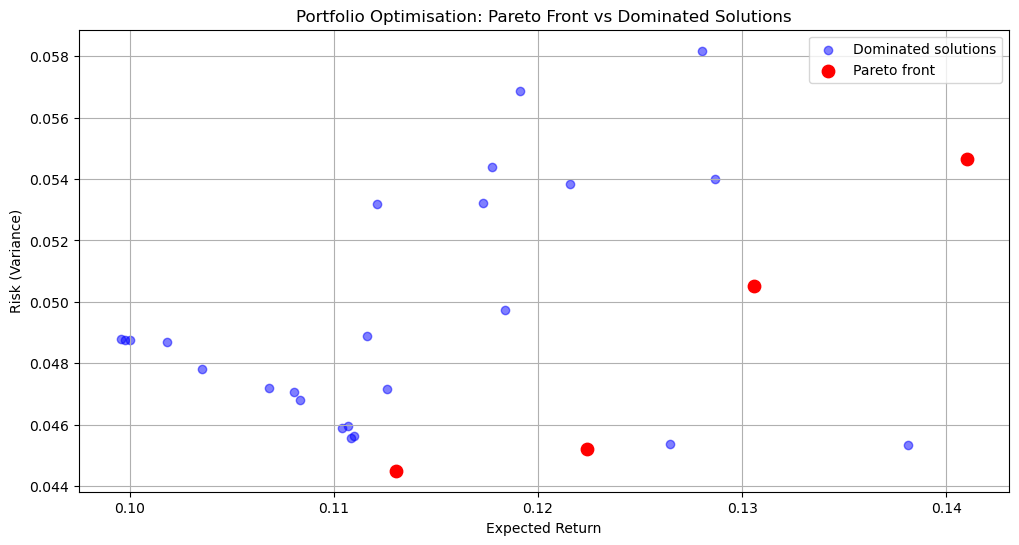

Number of Pareto‑optimal portfolios: 4


In [7]:
# Extract all solutions and dominated ones
all_solutions = np.array([ind.fitness.values for ind in pop_port])
front_points = np.array([ind.fitness.values for ind in front_port])

# Dominated solutions are those not in the front
dominated = [ind for ind in pop_port if ind not in front_port]
dominated_points = np.array([ind.fitness.values for ind in dominated]) if dominated else np.empty((0, 2))

plt.figure(figsize=(12, 6))
if len(dominated_points) > 0:
    plt.scatter(dominated_points[:, 0], dominated_points[:, 1], c='blue', alpha=0.5, label='Dominated solutions')
plt.scatter(front_points[:, 0], front_points[:, 1], c='red', s=80, label='Pareto front')
plt.xlabel('Expected Return')
plt.ylabel('Risk (Variance)')
plt.title('Portfolio Optimisation: Pareto Front vs Dominated Solutions')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of Pareto‑optimal portfolios: {len(front_port)}")

## Summary and Next Steps

**Accomplished:**
- Implemented multi‑objective optimisation using the **NSGA‑II** algorithm via the DEAP library.
- Applied it to two distinct problems:
  1. **Dent Problem** – a bi‑objective test function with a non‑smooth Pareto front. NSGA‑II successfully found a diverse set of non‑dominated solutions approximating the true front.
  2. **Portfolio Optimisation** – maximising expected return while minimising risk for 5 assets. The algorithm produced a Pareto front of 4 non‑dominated portfolios, showing the trade‑off between return and risk.
- Visualised the feasible solution space and the Pareto front for both problems, demonstrating the algorithm's ability to find well‑distributed solutions.

**Key Results:**

| Problem | Population | Generations | Pareto Front Size | Observations |
|---------|------------|-------------|-------------------|--------------|
| Dent | 50 | 10 | ~20 (visible) | Well‑distributed front capturing the "dent" shape |
| Portfolio | 30 | 5 | 4 | Clear trade‑off: higher return corresponds to higher risk |

**Key Insights:**
- **Multi‑objective optimisation** provides a set of trade‑off solutions (Pareto front) rather than a single optimal solution, enabling decision‑makers to choose based on preferences.
- **NSGA‑II** is effective for multi‑objective problems due to its fast non‑dominated sorting, crowding distance for diversity preservation, and elitism.
- **Constraint handling** (e.g., sum of weights = 1, non‑negative weights) can be implemented via custom operators or normalisation. Here, we used normalisation and custom crossover/mutation operators.
- The **Dent problem** highlights the algorithm's ability to handle non‑smooth Pareto fronts; the front found by NSGA‑II covers the key regions.
- For portfolio optimisation, the Pareto front confirms the fundamental trade‑off: higher expected return comes with higher risk, as expected in finance.
- The choice of genetic operators and parameters (population size, generations, mutation probability) affects the quality and diversity of the Pareto front.

**Suggested Next Steps:**
1. **Compare NSGA‑II with other multi‑objective algorithms** – e.g., MOEA/D, SPEA2, on the same problems.
2. **Add more objectives** – include liquidity, transaction costs, or sustainability criteria in the portfolio problem.
3. **Tune NSGA‑II parameters** – experiment with population size, mutation rate, crossover probability, and crowding distance to improve convergence and diversity.
4. **Incorporate real‑world constraints** – cardinality constraints (limit number of assets), sector exposure limits, or minimum investment thresholds.
5. **Apply to real financial data** – use historical returns and covariance matrices from actual assets (e.g., S&P 500 components).
6. **Implement performance metrics** – hypervolume, generational distance, inverted generational distance (IGD), and spread to quantitatively evaluate algorithm performance.
7. **Interactive visualisation** – build an interactive dashboard to explore the Pareto front and select preferred solutions.
8. **Extend to other domains** – engineering design, resource allocation, supply chain optimisation.

**Reflection:**
This notebook provides a comprehensive introduction to multi‑objective optimisation using genetic algorithms, with practical applications in both synthetic test functions and real‑world finance. The DEAP library offers a flexible and powerful framework for implementing custom operators and selection mechanisms. NSGA‑II remains a cornerstone algorithm in evolutionary multi‑objective optimisation, and its application to portfolio management illustrates its value in decision‑making under conflicting objectives. The visualisations clearly communicate the trade‑offs, and the modular design allows easy extension to more complex problems.